In [ ]:
import sys
import cnmf
import os

# Change path to wherever you have repo locally
sys.path.append('/oak/stanford/groups/engreitz/Users/ymo/Tools/PerturbNMF/src')

from Inference.src import (
    run_cnmf_consensus, get_top_indices_fast, annotate_genes_to_excel, \
    rename_and_move_files_NMF, rename_all_NMF, compile_results
)

import anndata as ad
import pandas as pd
import scanpy as sc

import warnings
warnings.filterwarnings("ignore")

In [ ]:
numiter=10  
numhvgenes=5451  
components = [30, 50, 60, 80, 100, 200, 250, 300] 
seed = 14
loss = 'frobenius'
init = 'random'
algo = 'cd'
species = "human"
max_NMF_iter = 1000
sel_threshs = [0.4, 0.8, 2.0]
tol = 1e-7
gene_num = 300
gene_names_key = "symbol"  # column in adata.var with gene names; set to None to use var_names

 
categorical_key="Day"
guide_assignment_key = "guide_assignment"
guide_names_key = "guide_names"
guide_targets_key = "guide_targets" 

counts_fn = "/oak/stanford/groups/engreitz/Users/ymo/cc-perturb-seq/Data/IGVF_D0_example.h5ad"
output_directory = "/oak/stanford/groups/engreitz/Users/ymo/NMF_re-inplementing/Results/sk-cNMF_evaluation/091425_100k_10iter_1000batiter_Htol_sk_cd_frobenius"
run_name = "091425_100k_10iter_1000batiter_Htol_sk_cd_frobenius_all"

In [ ]:
adata = sc.read(counts_fn)

In [ ]:
run_dir = f'{output_directory}/{run_name}'
cnmf_obj = cnmf.cNMF(output_dir=run_dir, name='Inference')

In [4]:
cnmf_obj.prepare(counts_fn= counts_fn, components= components, n_iter= numiter, densify=False, tpm_fn=None, seed= seed,
                beta_loss = loss, num_highvar_genes=numhvgenes, genes_file=None,
                alpha_usage=0.0, alpha_spectra=0.0, init=init, max_NMF_iter=max_NMF_iter, algo = algo, tol=tol)

/oak/stanford/groups/engreitz/Users/ymo/Tools/sk_cNMF/src/cnmf/cnmf.py:616: UserWarning: 80 runs already appear completed. If this is unexpected, consider
            re-initializing the cnmf object with a different run name or output directory
  warnings.warn(message, UserWarning)


In [ ]:
cnmf_obj.factorize(total_workers = 1,skip_completed_runs=True) 

[Worker 0]. Starting task 0.


In [5]:
cnmf_obj.combine()

Combining factorizations for k=30.
Combining factorizations for k=50.
Combining factorizations for k=60.
Combining factorizations for k=80.
Combining factorizations for k=100.
Combining factorizations for k=200.
Combining factorizations for k=250.
Combining factorizations for k=300.


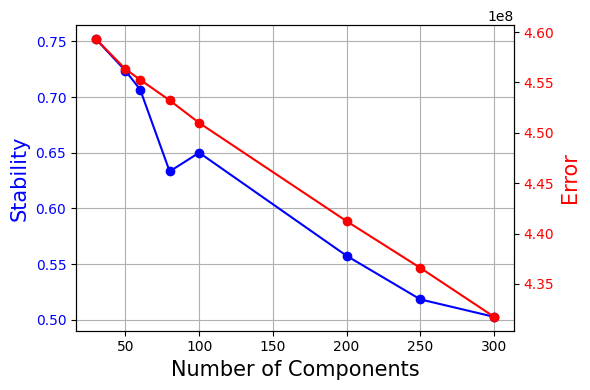

In [6]:
cnmf_obj.k_selection_plot()

In [5]:
# Consensus plots with all k to choose thresh

run_cnmf_consensus(cnmf_obj, 
                components=components , 
                density_thresholds=sel_threshs)

Running cNMF:   0%|          | 0/8 [00:00<?, ?it/s]/home/users/ymo/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/users/ymo/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/users/ymo/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
Running cNMF:  12%|█▎        | 1/8 [02:32<17:44, 152.12s/it]/home/users/ymo/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/users/ymo/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/users/ymo/.local/lib/python3.9/si

In [ ]:
# Save all cNMF scores in separate mudata objects
run_dir = f'{output_directory}/{run_name}'
compile_results(run_dir, 'Inference', components=components, sel_threshs=sel_threshs,
     guide_names_key=guide_names_key, guide_targets_key=guide_targets_key, categorical_key=categorical_key, 
     guide_assignment_key=guide_assignment_key, gene_names_key=gene_names_key)

In [ ]:
# annotation for all K
inference_dir = f'{output_directory}/{run_name}/Inference'
os.makedirs(f'{inference_dir}/Annotation', exist_ok=True)


for i in sel_threshs:
    for k in components:
        df = pd.read_csv('{inference_dir}/Inference.spectra.k_{k}.dt_{sel_thresh}.consensus.txt'.format(
                                                                                inference_dir=inference_dir,
                                                                                k=k,
                                                                                sel_thresh = str(i).replace('.','_')),
                                                                                sep='\t', index_col=0)   
        overlap = get_top_indices_fast(df, gene_num=gene_num)
        annotate_genes_to_excel(overlap, species = species, output_file = f'{inference_dir}/Annotation/{k}_{i}.xlsx')